In [1]:
install.packages(c(
  "readr", "dplyr", "ggplot2", "forecast", "tseries",
  "urca", "lmtest", "randtests", "nortest"
))

Warning message in install.packages(c("readr", "dplyr", "ggplot2", "forecast", "tseries", :
“installation of package ‘forecast’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [484]:
library(readr)
library(dplyr)
library(ggplot2)
library(forecast)
library(tseries)
library(urca)
library(lmtest)
library(randtests)
library(nortest)

In [485]:
data <- read.csv("data/cpiai.csv")
head(data)

,Date,Index,Inflation
,<chr>,<dbl>,<dbl>
1,1913-01-01,9.8,0.00
2,1913-02-01,9.8,0.00
3,1913-03-01,9.8,0.00
4,1913-04-01,9.8,0.00
5,1913-05-01,9.7,-1.02
6,1913-06-01,9.8,1.03


In [486]:
summary(data)

     Date               Index          Inflation     
 Length:1332        Min.   :  9.70   Min.   :-3.160  
 Class :character   1st Qu.: 17.50   1st Qu.: 0.000  
 Mode  :character   Median : 34.80   Median : 0.240  
                    Mean   : 87.26   Mean   : 0.261  
                    3rd Qu.:155.85   3rd Qu.: 0.550  
                    Max.   :307.79   Max.   : 5.880  

In [487]:
df1 <- data |>
  filter(Date >= "2010-01-01" & Date <= "2018-12-01") |>
  select(time = Date, y = Inflation)
dft <- data |>
  filter(Date >= "2019-01-01" & Date <= "2019-12-01") |>
  select(time = Date, y = Inflation)

In [488]:
head(df1)

,time,y
,<chr>,<dbl>
1,2010-01-01,0.34
2,2010-02-01,0.02
3,2010-03-01,0.41
4,2010-04-01,0.17
5,2010-05-01,0.08
6,2010-06-01,-0.10


In [489]:
df1 <- df1 |>
  mutate(time = as.Date(time, format = "%Y-%m-%d")) |>
  arrange(time)

dft <- dft |>
  mutate(time = as.Date(time, format = "%Y-%m-%d")) |>
  arrange(time)

In [490]:
head(df1)
tail(df1)

,time,y
,<date>,<dbl>
1,2010-01-01,0.34
2,2010-02-01,0.02
3,2010-03-01,0.41
4,2010-04-01,0.17
5,2010-05-01,0.08
6,2010-06-01,-0.10


,time,y
,<date>,<dbl>
103,2018-07-01,0.01
104,2018-08-01,0.06
105,2018-09-01,0.12
106,2018-10-01,0.18
107,2018-11-01,-0.33
108,2018-12-01,-0.32


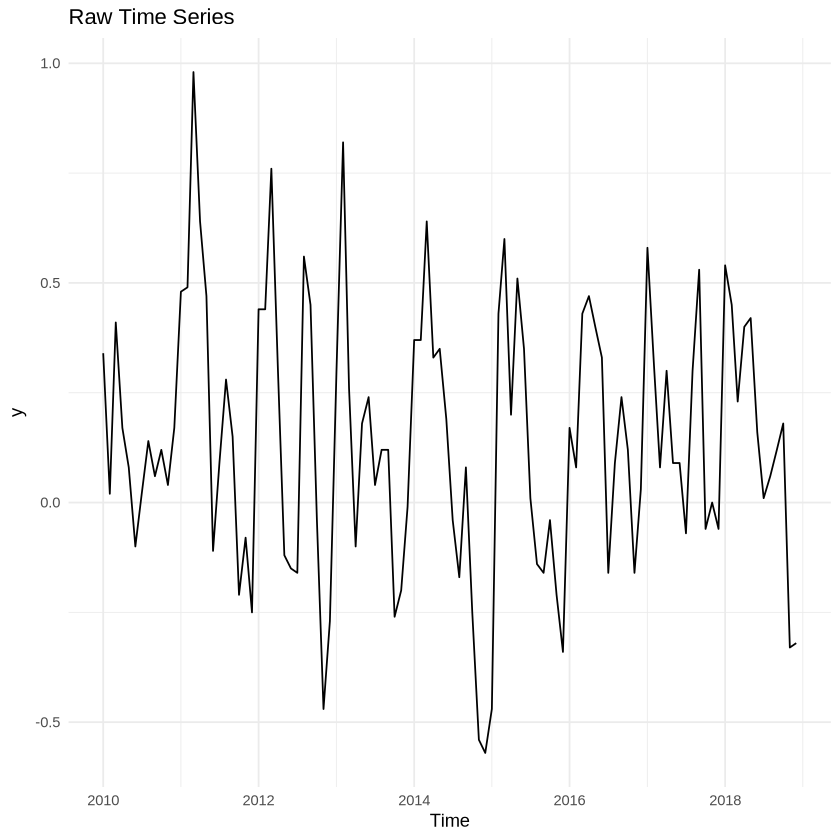

In [491]:
ggplot(df1, aes(x = time, y = y)) +
  geom_line() +
  labs(title = "Raw Time Series", x = "Time", y = "y") +
  theme_minimal()

In [492]:
summary(df1$y)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-0.5700 -0.0625  0.1200  0.1407  0.3550  0.9800 

In [493]:
y_ts  <- ts(df1$y, start = c(2010, 1), end = c(2018, 12), frequency = 12)
y_tst <- ts(dft$y, start = c(2019, 1), end = c(2019, 12), frequency = 12)


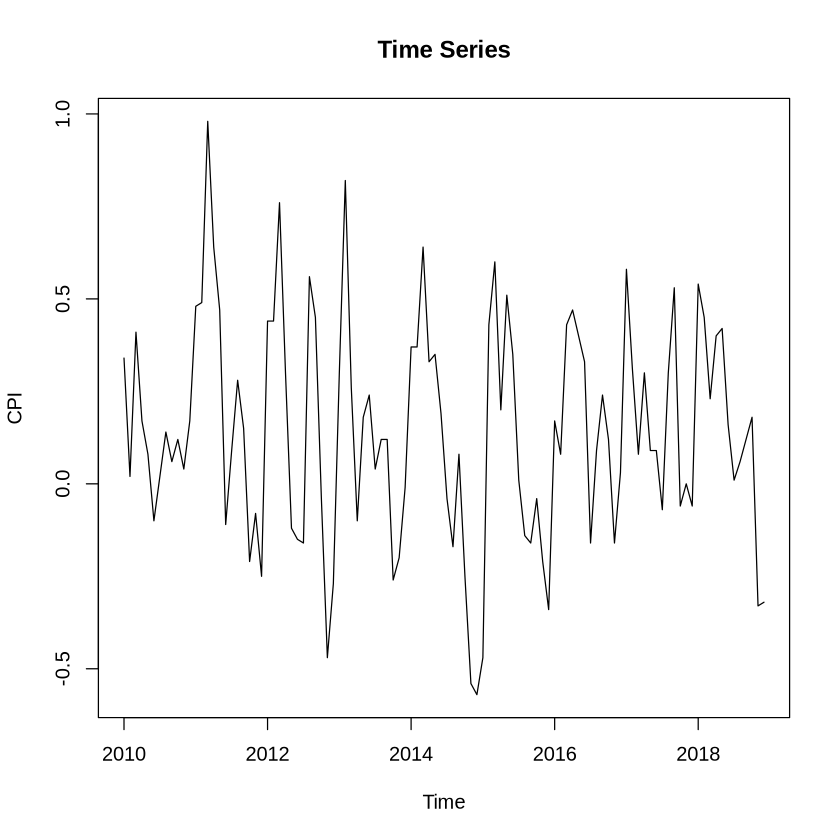

In [494]:
plot(y_ts, main = "Time Series", ylab = "CPI", xlab = "Time", )

In [495]:
lambda <- BoxCox.lambda(y_ts)
lambda

Warning message in guerrero(x, lower, upper):
“Guerrero's method for selecting a Box-Cox parameter (lambda) is given for strictly positive data.”


[1] 1.092825

No real need for variance stabalization

In [496]:
adf.test(y_ts)

Warning message in adf.test(y_ts):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  y_ts
Dickey-Fuller = -4.701, Lag order = 4, p-value = 0.01
alternative hypothesis: stationary


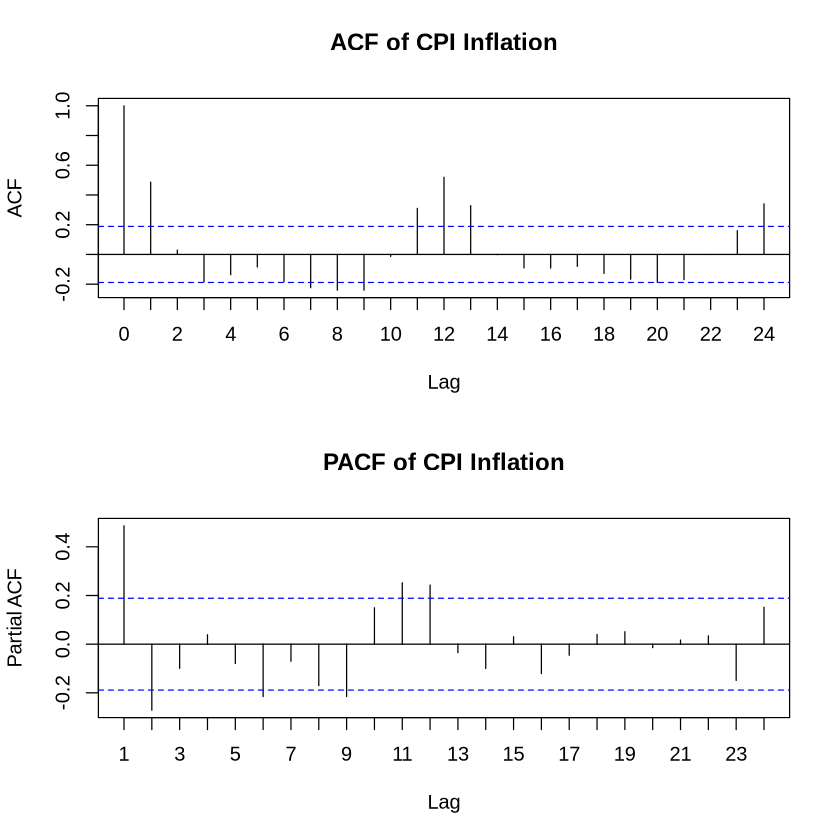

In [497]:
# ACF — lag.max=24 shows 2 years of lags as integers
par(mfrow = c(2, 1))

acf(y_ts,
    lag.max = 24,
    xaxt    = "n",          # suppress default axis
    main    = "ACF of CPI Inflation")
axis(1, at = 0:24/12, labels = 0:24)   # relabel as months

pacf(y_ts,
     lag.max = 24,
     xaxt    = "n",
     main    = "PACF of CPI Inflation")
axis(1, at = 1:24/12, labels = 1:24)

par(mfrow = c(1, 1))

# fitting

In [498]:
library(forecast)
arima_model <- auto.arima(y_ts, seasonal = TRUE,
                          stepwise = FALSE, approximation = FALSE)
summary(arima_model)

Series: y_ts 
ARIMA(0,0,1)(2,0,0)[12] with non-zero mean 

Coefficients:
         ma1    sar1    sar2    mean
      0.4199  0.3450  0.1970  0.1453
s.e.  0.0833  0.0969  0.1047  0.0577

sigma^2 = 0.0529:  log likelihood = 5.72
AIC=-1.43   AICc=-0.85   BIC=11.98

Training set error measures:
                       ME      RMSE       MAE MPE MAPE      MASE       ACF1
Training set -0.001209147 0.2257096 0.1811878 Inf  Inf 0.7513619 0.04543477


	Box-Ljung test

data:  res
X-squared = 21.136, df = 20, p-value = 0.3892



	Shapiro-Wilk normality test

data:  res[-1]
W = 0.99472, p-value = 0.9575



	Runs Test

data:  res[-1]
statistic = -0.58557, runs = 51, n1 = 53, n2 = 53, n = 106, p-value =
0.5582
alternative hypothesis: nonrandomness


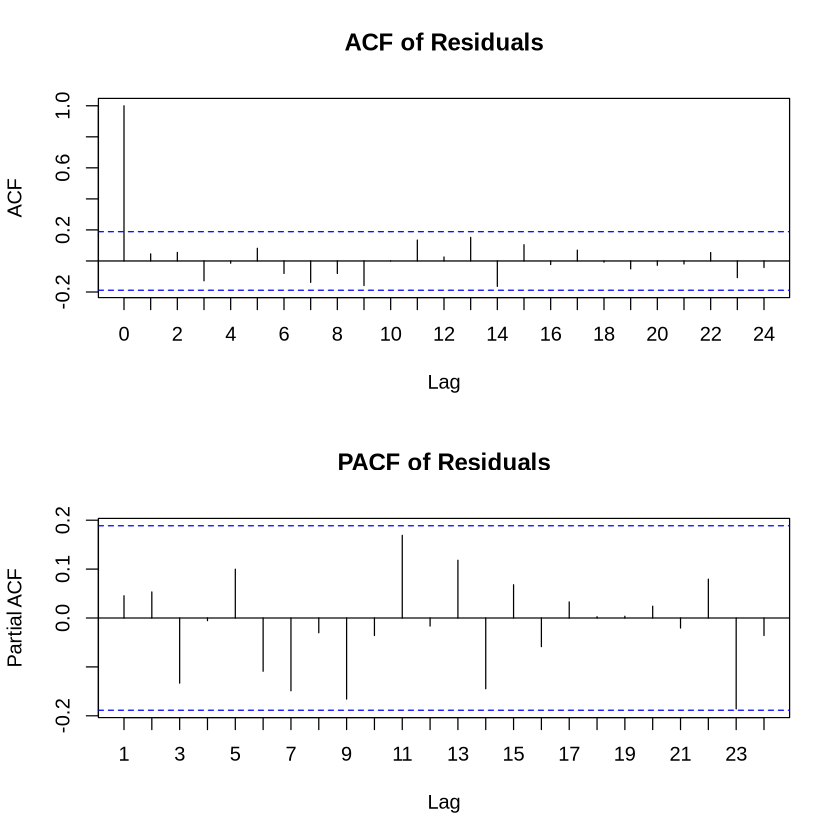

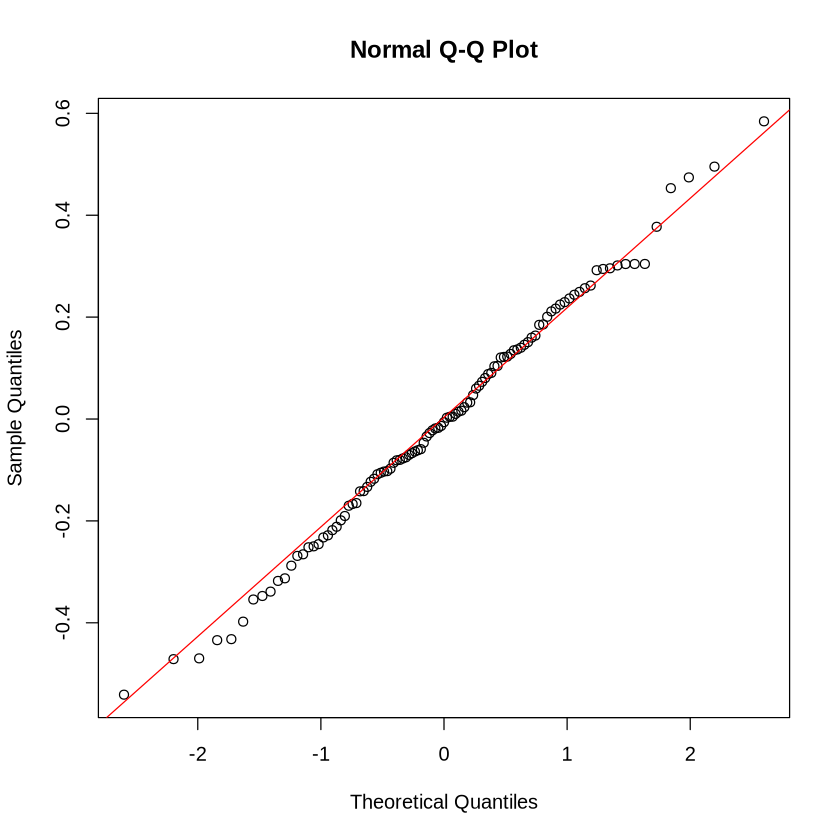

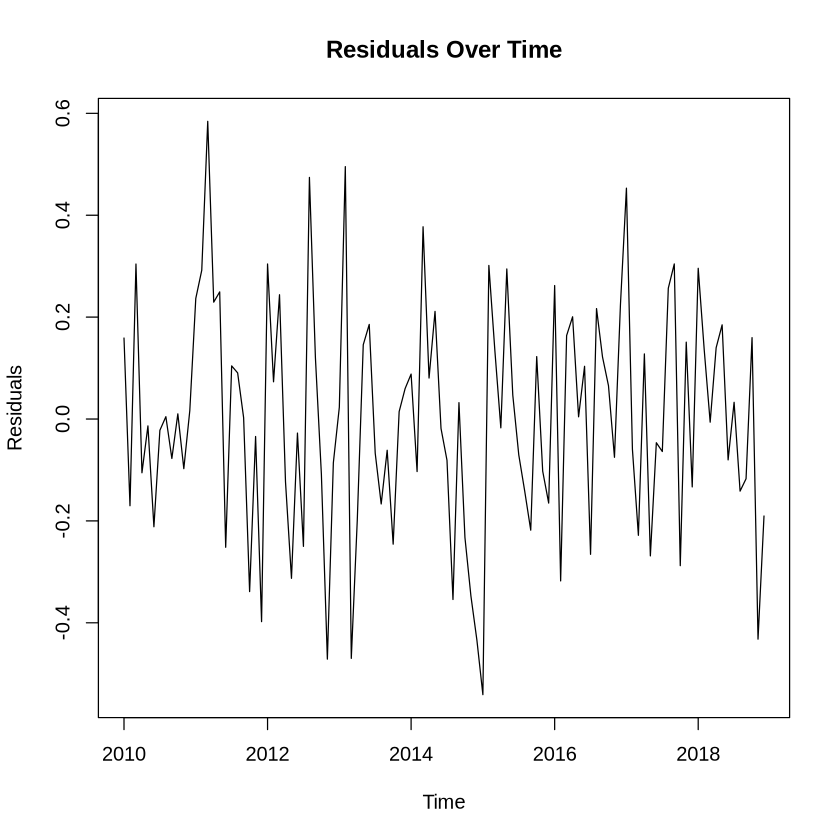

In [499]:
res <- residuals(arima_model)

Box.test(res, lag = 20, type = "Ljung-Box")
shapiro.test(res[-1])
runs.test(res[-1])

par(mfrow = c(2, 1))

acf(res,
    lag.max = 24,
    xaxt    = "n",
    main    = "ACF of Residuals")
axis(1, at = 0:24/12, labels = 0:24)

pacf(res,
     lag.max = 24,
     xaxt    = "n",
     main    = "PACF of Residuals")
axis(1, at = 1:24/12, labels = 1:24)

par(mfrow = c(1, 1))

qqnorm(res[-1])
qqline(res[-1], col = "red")
plot(res, type = "l", main = "Residuals Over Time", ylab = "Residuals")

In [500]:
fc <- forecast(arima_model, h = 12)

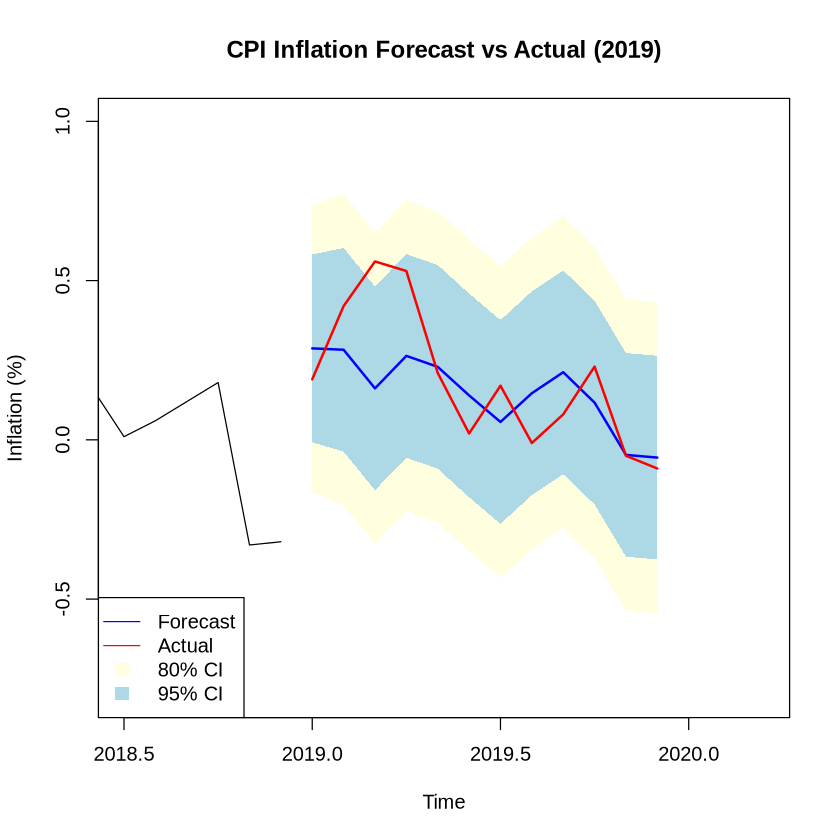

In [501]:
plot(fc,
     xlim = c(2018.5, 2020.2),  # shows full 2019
     ylim = c(-0.8, 1.0),
     main = "CPI Inflation Forecast vs Actual (2019)",
     ylab = "Inflation (%)", xlab = "Time",
     fcol  = "blue",
     shadecols = c("lightyellow", "lightblue"))

lines(y_tst, col = "red", lwd = 2)

legend("bottomleft",
       legend = c("Forecast", "Actual", "80% CI", "95% CI"),
       col    = c("blue", "red", "lightyellow", "lightblue"),
       lty    = c(1, 1, NA, NA),
       pch    = c(NA, NA, 15, 15),
       pt.cex = 1.5)

In [502]:
accuracy(fc, y_tst)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.001209147,0.2257096,0.1811878,Inf,Inf,0.7513619,0.04543477,NA
Test set,0.038936972,0.1686805,0.1325348,87.84986,225.0327,0.5496042,0.29041943,1.204311
